# Vehicle Silhouette Classification

A comparative analysis of supervised and unsupervised machine learning for classifying
vehicles from geometric silhouette features.

---

*   Author: Pawel Gebicki
*   Date: 03.03.2026


#**1. Setup and Initialization**

## 1.1 Import Libraries

We begin by importing the standard data science stack.
*   **Pandas/Numpy:** For data manipulation and linear algebra.
*   **Matplotlib/Seaborn:** For visualization.
*   **Sklearn:** Will be imported in later sections as needed for modeling.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visualization style for the whole project
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Load Dataset

In [6]:
# Load Dataset (Raw)
file_path = 'data/vehicle.csv'


try:
    # Loding the raw file
    df = pd.read_csv(file_path)
    print("Raw Dataset loaded successfully.")

    # Display first 5 rows
    display(df.head())

    # Check shape
    print(f"Shape: {df.shape}")

except FileNotFoundError:
    print("Error: vehicle.csv not found. Run this notebook from the repository root.")

Raw Dataset loaded successfully.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


Shape: (846, 19)


## 1.3 Data Dictionary

Before proceeding, we define the features extracted from the vehicle silhouettes. Understanding these geometric properties helps in interpreting the model's decisions later.

*   **Compactness**:   Measures how compact the shape is (area vs. perimeter).
*   **Circularity**:   How much the shape resembles a circle.
*   **Distance Circularity**:   The average distance from the center of the shape to the perimeter points.
*   **Radius Ratio**:   The ratio of the maximum radius to the minimum radius.
*   **Pr.Axis Aspect Ratio**:   Ratio of the minor axis to the major axis.
*   **Max.Length Aspect Ratio**:   Comparison of length vs width.
*   **Scatter Ratio**:   How "scattered" the pixels of the silhouette are (inertia).
*   **Elongatedness**:   Measures how long the vehicle looks (e.g., Buses are highly elongated).
*   **Pr.Axis Rectangularity**:   How much the shape fills its bounding box.
*   **Max.Length Rectangularity**:   Same as above, but regarding length.
*   **Scaled Variance (and .1)**:   Variance of the spatial distribution of the silhouette.
*   **Scaled Radius of Gyration (and .1)**:   Describes how the mass is distributed around the center.
*   **Skewness About (and .1, .2)**:   Measures asymmetry of the shape.
*   **Hollows Ratio**:   Measures the "holes" in the silhouette (e.g., windows, space between wheels).

#**2. Data Cleaning and Preparation**

## 2.1 Clarity of the dataset

In [7]:
# Initial Inspection of Data Types
print("--- Data Types Before Cleaning ---")
df.info()

--- Data Types Before Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null  

##2.2 Target Variable Verification

In [8]:
# Target Variable Verification
# We confirm that the classes are already grouped into the 3 business categories.

unique_classes = df['class'].unique()
print(f"Unique classes found: {unique_classes}")

# Boolean check for the presentation
expected_classes = {'car', 'bus', 'van'}
current_classes = set(unique_classes)

if current_classes == expected_classes:
    print("✅ Target variable is correctly grouped. No mapping needed.")
else:
    print("⚠️ Unexpected classes found! Please check the data dictionary.")

Unique classes found: ['van' 'car' 'bus']
✅ Target variable is correctly grouped. No mapping needed.


## 2.3 Handling Duplicates
Duplicate rows can bias the model evaluation and distort statistical analysis. We identify and remove them before proceeding.

In [9]:
# Count duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

if duplicates > 0:
    # Save shape before
    shape_before = df.shape

    # Drop duplicates
    df.drop_duplicates(inplace=True)

    print(f"Duplicates removed. Shape changed from {shape_before} to {df.shape}.")

    # Reset index after dropping rows to keep the dataframe clean
    df.reset_index(drop=True, inplace=True)
else:
    print("✅ No duplicates found. Dataset is clean.")

Number of duplicate rows found: 0
✅ No duplicates found. Dataset is clean.


##2.4 Missing Value Analysis

In [10]:
# Missing Value Analysis
# Checking the missing values in order to understand better data quality. Not handling the missing values in this step.
# Handling the missing values will be proceed after the splitting and before training.


# Count missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    print("--- Missing Values Detected ---")
    display(missing.to_frame(name='Count'))

    # Calculate percentage of rows affected
    total_rows = len(df)
    rows_with_nan = df.isnull().any(axis=1).sum()
    print(f"\nTotal rows with at least one missing value: {rows_with_nan} out of {total_rows}")
    print(f"Percentage of data affected: {(rows_with_nan/total_rows)*100:.2f}%")

else:
    print("✅ No missing values found.")

--- Missing Values Detected ---


,Count
radius_ratio,6
skewness_about,6
circularity,5
distance_circularity,4
scaled_radius_of_gyration.1,4
pr.axis_rectangularity,3
scaled_variance,3
scaled_radius_of_gyration,2
pr.axis_aspect_ratio,2
scaled_variance.1,2



Total rows with at least one missing value: 33 out of 846
Percentage of data affected: 3.90%


## 2.5 Feature Standardization

In [11]:
#Rename the target column from `class` (a Python keyword) to `target`in order to avoid conflict with Python's 'class' keyword.
df = df.rename(columns={'class': 'target'})

# Verify the change
print(f"Columns: {df.columns.tolist()}")

Columns: ['compactness', 'circularity', 'distance_circularity', 'radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1', 'skewness_about.2', 'hollows_ratio', 'target']


#**3. Exploratory Data Analysis (EDA)**

## 3.1 Target Variable Analysis

--- Class Proportions ---
target
car    0.51
bus    0.26
van    0.24
Name: proportion, dtype: float64

--- Visualization - Target Variable Distribution ---


/tmp/ipykernel_210/3105041864.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis', order=class_distribution.index)


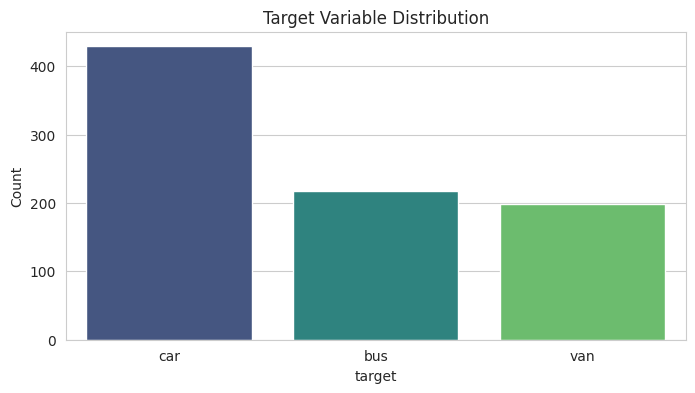

In [12]:
# Calculate Proportions
class_distribution = df['target'].value_counts(normalize=True).round(2)
print("--- Class Proportions ---")
print(class_distribution)

# Visualizazion
print("\n--- Visualization - Target Variable Distribution ---")
plt.figure(figsize=(8, 4))
sns.countplot(x='target', data=df, palette='viridis', order=class_distribution.index)
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.show()

## 3.2 Univariate Analysis (Numerical Features)

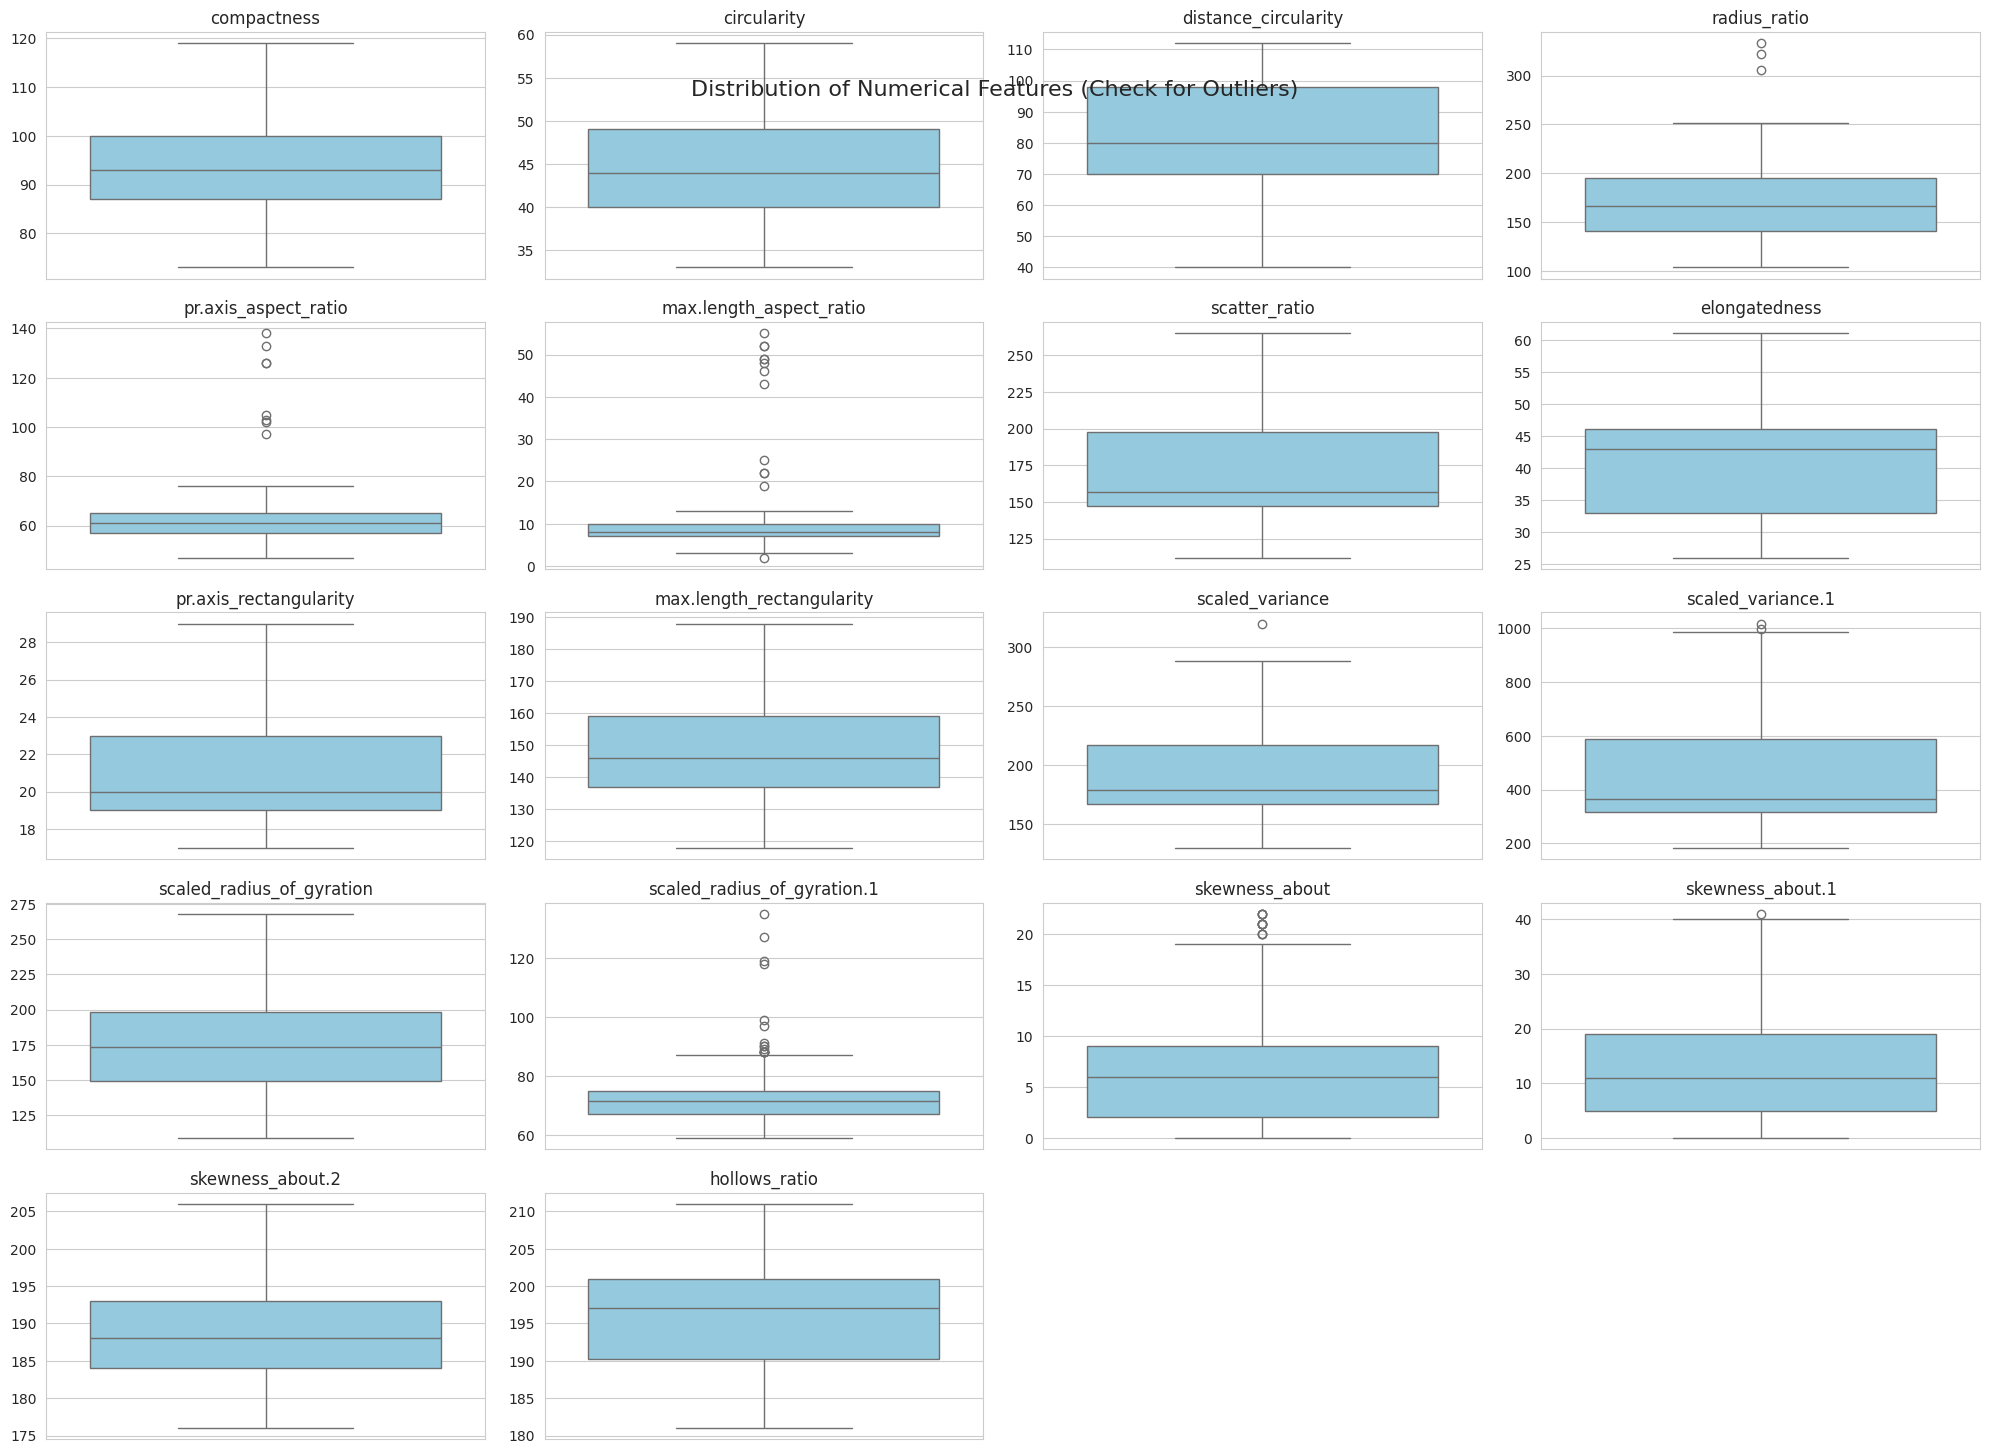

In [13]:
# 3.2 Feature Distributions (Boxplots)

# 1. Selecting only numerical columns (dropping the target)
# Using select_dtypes to be safe
numeric_cols = df.select_dtypes(include=np.number).columns

# 2. Creating the Canvas (Big figure)
plt.figure(figsize=(20, 15))
# Adding the title
plt.suptitle('Distribution of Numerical Features (Check for Outliers)', fontsize=16, y=0.92)

# 3. The Loop -> Drawing 18 little plots
for i, col in enumerate(numeric_cols):
    # Creating a subplot grid (5 rows, 4 columns)
    plt.subplot(5, 4, i + 1)

    # Drawing the boxplot
    sns.boxplot(y=df[col], color='skyblue')

    # Adding the title for each little plot
    plt.title(col)
    plt.ylabel('') # Remove y-label to save space

# Adjusting spacing so titles don't overlap
plt.tight_layout()
plt.show()

## 3.3 Bivariate Analysis (Correlation Heatmap)

We analyze now the relationships between numerical features to identify redundant data. High correlation indicates that two features provide nearly identical information.

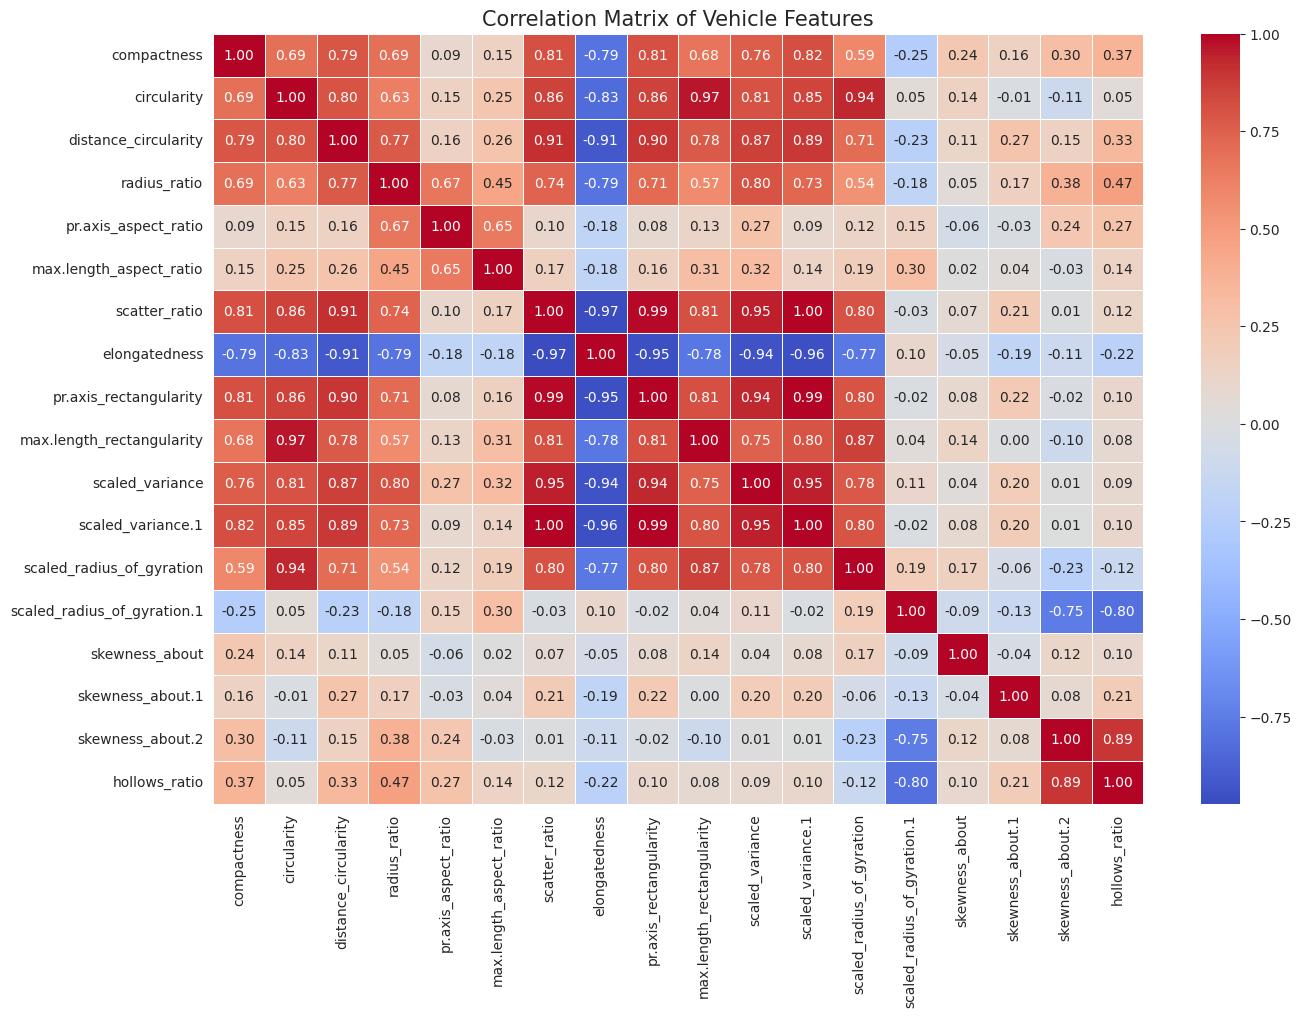

In [14]:
# Calculate the correlation matrix
corr_matrix = df.drop('target', axis=1).corr()

# Setup the figure size
plt.figure(figsize=(15, 10))

# Creating the heatmap
# Explenations for the code:
# annot=True: shows the numbers inside the squares
# cmap='coolwarm': red for high correlation, blue for low
# fmt='.2f': shows only 2 decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Vehicle Features', fontsize=15)
plt.show()

### 3.3.1 Redundancy Removal
Based on the high correlation (r >= 0.95) observed in the previous heatmap, redundant features were removed. These features provide nearly identical information, and removing them simplifies our feature space without losing predictive power.

In [15]:
# Dropping Redundant Features

# Features for removal based on the heatmap
to_drop = ['scaled_variance.1',  # 1.00 with scatter_ratio
    'pr.axis_rectangularity',    # 0.99 with scatter_ratio
    'max.length_rectangularity', # 0.97 with scatter_ratio
    'elongatedness',             # -0.97 with scatter_ratio
    'scaled_variance'            # 0.95 with scatter_ratio
]

# Apply the drop
df = df.drop(columns=to_drop)

print(f"Removed: {to_drop}")
print(f"New shape of the dataset: {df.shape}")

Removed: ['scaled_variance.1', 'pr.axis_rectangularity', 'max.length_rectangularity', 'elongatedness', 'scaled_variance']
New shape of the dataset: (846, 14)


### 3.3.2 Post-Removal Heatmap

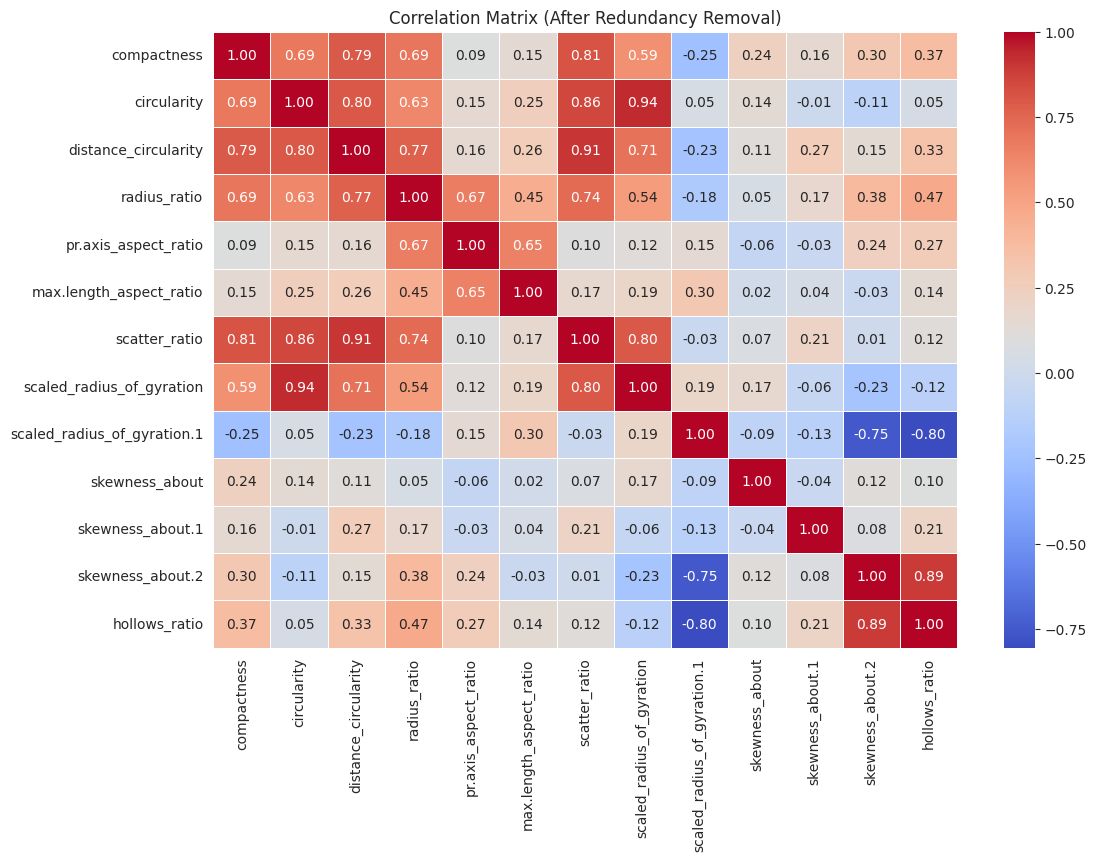

In [16]:
#Showing the correlation matrix ahain in order to confirm that extreme multicollinearity has been resolved.

plt.figure(figsize=(12, 8))

sns.heatmap(df.drop('target', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix (After Redundancy Removal)')
plt.show()

**Interpretation of the Cleaned Correlation Matrix:**
*   **Success of Redundancy Removal:** The extreme multicollinearity (|r| >= 0.95) has been completely resolved. The feature space is now leaner and mathematically stable.
*   **Remaining Relationships:** The highest remaining correlation is between `circularity` and `scaled_radius_of_gyration` (0.94).
*   **Strategic Decision:** We intentionally retain these strongly correlated features. While they share similarities, the remaining variance (unexplained by correlation) captures the subtle geometric nuances necessary for non-linear models (like Random Forest or SVM) to differentiate between visually similar vehicles (e.g., Vans vs. Cars).

##3.4 Multivariate Analysis (Class Separability)

To conclude our EDA, we visualize how well our cleaned features separate the three vehicle classes. We use a pairplot on a subset of descriptive features, coloring the data points by the target variable. Distinct clusters will indicate that our classification models have a high chance of success.

Generating Pairplot... (This takes a few seconds)


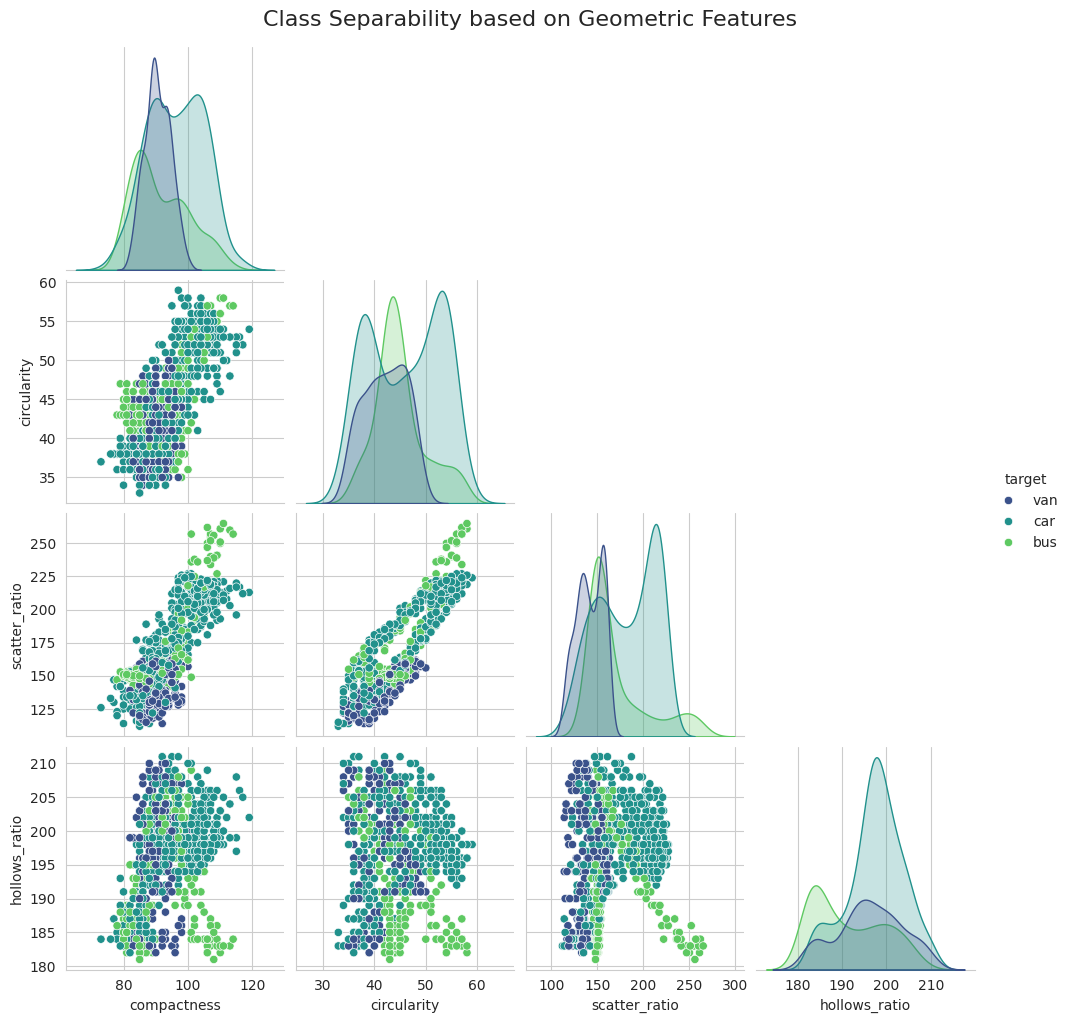

In [17]:
# We select 4 distinct features from our cleaned dataset
# We include 'target' so Seaborn knows how to color the dots
features_to_plot = ['compactness', 'circularity', 'scatter_ratio', 'hollows_ratio', 'target']

print("Generating Pairplot... (This takes a few seconds)")

# Create the plot
# hue='target' colors the points (e.g., Bus, Car, Van)
# corner=True removes the duplicate top-right half of the grid to keep it clean
sns.pairplot(df[features_to_plot], hue='target', palette='viridis', diag_kind='kde', corner=True)

plt.suptitle('Class Separability based on Geometric Features', y=1.02, fontsize=16)
plt.show()

**Interpretation of Class Separability (Multivariate Analysis):**

Based on the pairplot, we can draw several critical conclusions about how our future models will perform:

*   **The "Golden" Feature (`hollows_ratio`):** Looking at the bottom right diagonal plot, `hollows_ratio` is incredibly powerful. The distribution shows three distinct peaks: 'bus' on the left, 'car' forming a massive spike in the middle, and 'van' on the right. This feature alone will be a primary driver for our model's decisions.
*   **The "Bus" is easily distinguishable:** In the `scatter_ratio` diagonal plot, the 'bus' class is shifted entirely to the right, separate from cars and vans. In scatter plots like `scatter_ratio` vs `hollows_ratio`, the light green dots form their own isolated "island." We expect our model to classify buses with near-perfect accuracy.
*   **The "Car vs. Van" Challenge:** As anticipated by the business problem, cars and vans are geometrically very similar. In features like `compactness` and `circularity`, their distributions are stacked directly on top of each other, and their scatter points are heavily mixed.
*   **Conclusion for Modeling:** Because the classes are not easily separated by simple straight lines in most dimensions, basic linear models (like Logistic Regression) may struggle. We will likely need advanced, non-linear algorithms (like Random Forest or Support Vector Machines) to find the complex boundaries between Cars and Vans.

#**4. Data Preprocessing**

In this phase, we prepare the dataset for the Machine Learning algorithms. To prevent **Data Leakage**, we must split the data into Training and Testing sets *before* applying any transformations (like imputation or scaling).

## 4.1 Train-Test Split (Stratified)
We separate our features (`X`) from our target variable (`y`). We allocate 80% of the data for training and reserve 20% for final testing.
Crucially, we use **Stratified Splitting** to guarantee that the 50/25/25 ratio of Cars/Buses/Vans is perfectly preserved in both the Train and Test sets.

In [18]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Perform the Split
# test_size=0.2: 20% goes to the Test set
# stratify=y: Forces the Train/Test sets to have the same class balance as 'y'
# random_state=42: Ensures we get the exact same split every time we run the notebook
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Verification
print(f"Original dataset shape: {df.shape}")
print("-" * 35)
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

# Prove that stratification worked
print("\n--- Class Proportions in Train Set ---")
print(y_train.value_counts(normalize=True).round(2))

print("\n--- Class Proportions in Test Set ---")
print(y_test.value_counts(normalize=True).round(2))

Original dataset shape: (846, 14)
-----------------------------------
X_train shape: (676, 13) | y_train shape: (676,)
X_test shape:  (170, 13)  | y_test shape:  (170,)

--- Class Proportions in Train Set ---
target
car    0.51
bus    0.26
van    0.24
Name: proportion, dtype: float64

--- Class Proportions in Test Set ---
target
car    0.51
bus    0.26
van    0.24
Name: proportion, dtype: float64


## 4.2 Handling Missing Values (Imputation)

We previously identified a small number of missing values. We use `SimpleImputer` to replace these `NaN` values with the median of their respective columns.

**Preventing Data Leakage:** The imputer calculates the median strictly from the Training set (`X_train`). These learned values are then used to fill missing data in both the Training and Testing sets. The Test set is never used to calculate the replacement values.

In [19]:
from sklearn.impute import SimpleImputer


# --- THE BEFORE PICTURE ---
print("BEFORE IMPUTATION:")
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isnull().sum().sum()}")
print("-" * 30)

# 1. Initialize the Imputer (using 'median' due to outliers found in EDA)
imputer = SimpleImputer(strategy='median')

# 2. Fit and Transform the Training Data
# Learns the median from X_train, and fills holes in X_train
X_train_imputed = imputer.fit_transform(X_train)

# 3. Transform the Testing Data
# ONLY fills the holes in X_test using the medians learned from X_train
X_test_imputed = imputer.transform(X_test)

# 4. Restore Pandas DataFrames (to keep our column names for the models)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# --- THE AFTER PICTURE ---
print("AFTER IMPUTATION:")
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isnull().sum().sum()}")

BEFORE IMPUTATION:
Missing values in X_train: 22
Missing values in X_test:  10
------------------------------
AFTER IMPUTATION:
Missing values in X_train: 0
Missing values in X_test:  0


## 4.3 Feature Scaling (Standardization)

During EDA, we observed that our features operate on vastly different scales (e.g., `compactness` is around 90, while `scaled_variance` is around 200). Distance-based algorithms (like SVM) and gradient-descent models are highly sensitive to this disparity.

We use `StandardScaler` to center the data around a mean of 0 with a standard deviation of 1.

**Preventing Data Leakage:** The scaler learns the mean and standard deviation strictly from the Training set, and then applies that exact mathematical transformation to both the Train and Test sets.

In [20]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform Training Data
# The scaler learns the Mean and Std Dev of X_train, and scales the data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform Testing Data
# The scaler applies the EXACT math it learned from Step 2 to the test data
X_test_scaled = scaler.transform(X_test)

# 4. Restore Pandas DataFrames
# Scikit-learn outputs raw numpy arrays. We wrap them back into DataFrames to keep column names.
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# 5. Verification
print("--- Data AFTER Scaling (First 3 rows of X_train) ---")
display(X_train.head(3).round(3))

--- Data AFTER Scaling (First 3 rows of X_train) ---


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
508,0.166,0.194,0.619,-0.307,0.142,0.466,-0.270,-0.111,-0.318,0.116,0.932,0.006,0.586
396,1.749,-0.136,1.511,0.228,-1.297,-0.738,2.657,2.693,1.916,0.924,-1.158,-1.149,-2.006
51,-0.199,-1.127,-0.720,0.139,0.502,-0.336,-0.453,-1.389,-0.318,-0.490,1.262,0.006,-0.096


#**5. Model Training and Validation**

In this phase, we apply supervised learning algorithms to classify the vehicle silhouettes.
Our strategy involves:
1. **Establishing a Baseline:** Using a simple linear model (Logistic Regression).
2. **Evaluation Strategy:** Using 5-Fold Stratified Cross-Validation on the training data to ensure robust scoring without touching the hold-out test set.
3. **Primary Metric:** We use **Macro F1-Score** alongside Accuracy. Because our dataset has a moderate imbalance (~50% Cars), Macro F1 ensures we penalize models that ignore the minority classes (Vans/Buses).

## 5.1 Baseline Model: Logistic Regression
We begin with Logistic Regression to set a performance benchmark. It is highly interpretable and fast, though it assumes linear boundaries between classes.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold


# 1. Initialize the Model
# max_iter=1000 ensures the algorithm has enough time to find the math solution
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Setup the Cross-Validation Strategy
# We use StratifiedKFold to maintain the 50/25/25 balance in all 5 mini-tests
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Grade the Model (Cross-Validation)
# We calculate both Accuracy and Macro F1-Score
cv_accuracy = cross_val_score(log_reg, X_train, y_train, cv=skf, scoring='accuracy')
cv_f1_macro = cross_val_score(log_reg, X_train, y_train, cv=skf, scoring='f1_macro')

# 4. Display Results
print("--- Baseline Model: Logistic Regression ---")
print(f"CV Accuracy Scores (5 folds): {cv_accuracy.round(3)}")
print(f"Mean CV Accuracy:             {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")
print("-" * 40)
print(f"CV F1-Macro Scores (5 folds): {cv_f1_macro.round(3)}")
print(f"Mean CV F1-Macro:             {cv_f1_macro.mean():.3f}")

--- Baseline Model: Logistic Regression ---
CV Accuracy Scores (5 folds): [0.949 0.941 0.911 0.941 0.941]
Mean CV Accuracy:             0.936 (+/- 0.026)
----------------------------------------
CV F1-Macro Scores (5 folds): [0.95  0.937 0.899 0.94  0.935]
Mean CV F1-Macro:             0.932


## 5.2 Advanced Models Comparison
Our baseline Logistic Regression performed exceptionally well (~93.2% F1-Macro). To see if we can capture the more complex, non-linear boundaries between 'Cars' and 'Vans' identified during EDA, we evaluate two advanced algorithms:
1. **Support Vector Classifier (SVC):** Effective in high-dimensional spaces and capable of finding non-linear geometric boundaries.
2. **Random Forest Classifier:** A robust, tree-based ensemble method that handles complex feature interactions well.

We use the exact same 5-Fold Cross-Validation strategy to ensure a fair comparison.

In [22]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Define the models with standard starting parameters
models = {
    "Support Vector Machine (SVM)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Loop through the models and grade them
print("--- Advanced Models Evaluation (Cross-Validation) ---\n")

# We will save the mean F1 scores to compare later
results_f1 = {'Logistic Regression': cv_f1_macro.mean()}

for name, model in models.items():
    # We use the same 'skf' (StratifiedKFold) defined in step 5.1 for a fair fight!
    cv_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_f1 = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_macro')

    # Save the F1 score
    results_f1[name] = cv_f1.mean()

    # Print results
    print(f"--- {name} ---")
    print(f"Mean CV Accuracy: {cv_acc.mean():.3f} (+/- {cv_acc.std() * 2:.3f})")
    print(f"Mean CV F1-Macro: {cv_f1.mean():.3f}")
    print("-" * 40)

# 3. Quick Summary of Winners
print("\n LEADERBOARD (Macro F1-Score)")
for name, score in sorted(results_f1.items(), key=lambda item: item[1], reverse=True):
    print(f"{name:<30}: {score:.3f}")

--- Advanced Models Evaluation (Cross-Validation) ---

--- Support Vector Machine (SVM) ---
Mean CV Accuracy: 0.935 (+/- 0.043)
Mean CV F1-Macro: 0.928
----------------------------------------
--- Random Forest ---
Mean CV Accuracy: 0.948 (+/- 0.039)
Mean CV F1-Macro: 0.945
----------------------------------------

 LEADERBOARD (Macro F1-Score)
Random Forest                 : 0.945
Logistic Regression           : 0.932
Support Vector Machine (SVM)  : 0.928


## 5.3 Hyperparameter Tuning (Random Forest)

Our evaluation showed that Random Forest is the best performing model. To maximize its predictive power, we perform Hyperparameter Tuning using `GridSearchCV`.

We will test various combinations of:
*   `n_estimators`: The number of trees in the forest.
*   `max_depth`: The maximum depth of each tree (to prevent overfitting).
*   `min_samples_split`: The minimum number of samples required to split an internal node.

We optimize specifically for the **Macro F1-Score**.

In [23]:

from sklearn.model_selection import GridSearchCV

# 1. Define the Grid (The settings we want to test)
param_grid = {
    'n_estimators': [100, 200, 300],       # How many trees?
    'max_depth': [None, 10, 20],           # How tall can the trees grow? (None = infinite)
    'min_samples_split': [2, 5, 10]        # How strict are the rules for branching?
}

# 2. Initialize the Base Model
rf_base = RandomForestClassifier(random_state=42)

# 3. Setup the Grid Search
# cv=skf ensures we still use our strict 5-Fold Stratified validation
# n_jobs=-1 tells the computer to use ALL of its processor cores to run this faster
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1 # This prints out a progress bar so we know it's working
)

# 4. Run the Search
print("Starting Grid Search... testing 27 combinations.")
grid_search.fit(X_train, y_train)

# 5. Print the Results
print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best CV F1-Macro Score: {grid_search.best_score_:.3f}")

# 6. Save the ultimate winner as our final model
best_rf_model = grid_search.best_estimator_

Starting Grid Search... testing 27 combinations.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Tuning Complete ---
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Macro Score: 0.945


#**6. Final Model Evaluation (On Unseen Test Data)**

We now evaluate our optimized Random Forest model on the 20% hold-out Test Set. This is the ultimate test of the model's ability to generalize to new, unseen vehicle silhouettes.

We will analyze the performance using:
1. **Classification Report:** To check Precision, Recall, and F1-Score per class.
2. **Confusion Matrix:** To visually identify if the model still confuses 'Cars' with 'Vans' as hypothesized during EDA.

## 6.1 Final Evaluation on the Test Set

FINAL TEST ACCURACY: 95.29%

--- Classification Report ---
              precision    recall  f1-score   support

         bus       0.93      0.98      0.96        44
         car       0.98      0.93      0.95        86
         van       0.93      0.97      0.95        40

    accuracy                           0.95       170
   macro avg       0.95      0.96      0.95       170
weighted avg       0.95      0.95      0.95       170



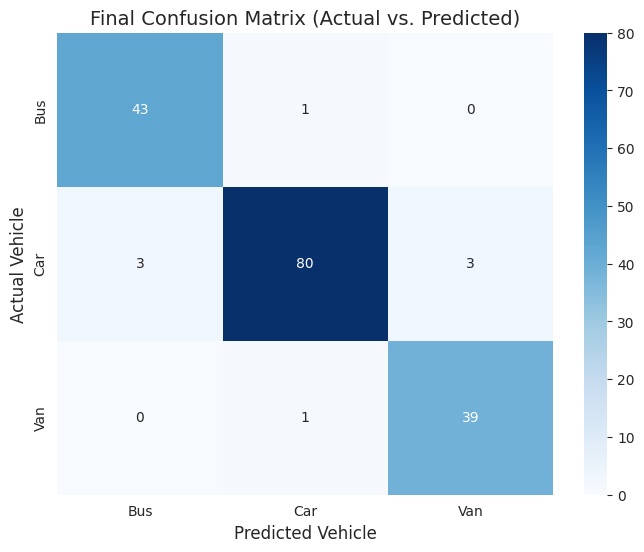

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# 1. The Test
# Notice we use 'best_rf_model' which was saved at the end of our Grid Search
y_pred = best_rf_model.predict(X_test)

# 2. Calculating Final Scores
final_acc = accuracy_score(y_test, y_pred)
print(f"FINAL TEST ACCURACY: {final_acc * 100:.2f}%\n")

# 3. Printing the detailed Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 4. Generating the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['bus', 'car', 'van'])

# 5. Visualizing the Confusion Matrix (The ultimate presentation slide)
plt.figure(figsize=(8, 6))
# annot=True shows the numbers, fmt='d' ensures they are whole numbers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bus', 'Car', 'Van'],
            yticklabels=['Bus', 'Car', 'Van'])

plt.title('Final Confusion Matrix (Actual vs. Predicted)', fontsize=14)
plt.xlabel('Predicted Vehicle', fontsize=12)
plt.ylabel('Actual Vehicle', fontsize=12)
plt.show()

## 6.2 Final Analytical Conclusion



The optimized Random Forest model achieved **95.29% accuracy** on the unseen test set, proving that it generalizes exceptionally well without overfitting.

**Detailed Insights from the Confusion Matrix:**
1. **Exceptional Recall on Extreme Shapes (Buses & Vans):**
   The model correctly identified 43 out of 44 Buses and 39 out of 40 Vans.
2. **The 'Car' Category Challenge:**
   The only noticeable friction point is within the 'Car' class. Out of 86 actual cars, 6 were misclassified (3 as buses, 3 as vans).
3. **Business Impact:**
   For "Prospect Auto," this model is highly production-ready. With a macro F1-score of 0.95, it proves that geometric silhouette features, when scaled and processed through a non-linear ensemble algorithm, are sufficient to distinguish between these three vehicle classes with high commercial reliability.

---
# ==========================================
# PART II: UNSUPERVISED METHODS
# ==========================================
---
In this second phase, we discard the target labels during the training process. Our goal is to determine if mathematical algorithms can naturally discover the underlying structure (the 3 vehicle types) using only the geometric relationships of the data.

#**7. Data Preparation for Unsupervised Learning**

To properly evaluate Dimensionality Reduction (PCA), we must provide the algorithm with the **original 18 features**. In Part 1, we manually dropped highly correlated features. Here, we will reload the dataset and allow PCA to handle the multicollinearity mathematically.

**Pipeline Steps:**
1.  **Reload & Clean:** Reload the raw data, standardize labels (Car, Bus, Van), and drop duplicates.
2.  **Train/Test Split:** Per the project requirements, we split the data 80/20 using stratification.
3.  **Imputation & Scaling:** We apply median imputation and standard scaling, fitting strictly on the training set to prevent data leakage.

## 7.1 Reload and Clean
To properly evaluate Dimensionality Reduction (PCA), we must provide the algorithm with the **original 18 features**. We reload a fresh copy of the dataset and apply our basic cleaning (label standardization and duplicate removal).

In [25]:
# 1. Load the raw data. Using na_values to catch empty strings
df_unsup = pd.read_csv('data/vehicle.csv', na_values=['', ' ', '?'])

# 2. Rename target column for consistency
df_unsup.rename(columns={'class': 'target'}, inplace=True)

# 3. Clean the rows (Drop duplicates)
df_unsup.drop_duplicates(inplace=True)
df_unsup.reset_index(drop=True, inplace=True)

print(f"Dataset reloaded. Total columns: {df_unsup.shape[1]}")

Dataset reloaded. Total columns: 19


## 7.2 Train-Test Split (The "Hidden" Target)
In Unsupervised Learning, the algorithms must not see the labels. We separate the features (`X`) from the target (`y`). The algorithms will only be trained on `X`. We retain `y` purely as a "hidden answer key" to evaluate the clustering performance at the very end of the project.

In [26]:
# 1. Separate the Data and hide the 'answer' column
# X_un contains ONLY the 18 geometric features.
X_un = df_unsup.drop('target', axis=1)

# y_un is the answer key and we keep it for further check up
y_un = df_unsup['target']

# 2. The Split (Stratified 80/20)
# We add '_u' to the variables so they don't overwrite our Part 1 variables
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_un, y_un, test_size=0.2, stratify=y_un, random_state=42
)

print(f"Features ready for PCA: {X_train_u.shape[1]} (Original 18 dimensions)")

Features ready for PCA: 18 (Original 18 dimensions)


## 7.3 Imputation and Scaling
Unsupervised algorithms (like PCA and K-Means) measure geometric distances between points. They are highly sensitive to unscaled data. We apply median imputation and StandardScaler strictly fitted on the training data to create a level mathematical playing field.

In [27]:
# 1. Initialize the tools
imputer_u = SimpleImputer(strategy='median')
scaler_u = StandardScaler()

# 2. The Training Pipeline (Fit & Transform)
X_train_clean = imputer_u.fit_transform(X_train_u)
X_train_scaled = scaler_u.fit_transform(X_train_clean)

# 3. The Testing Pipeline (Transform ONLY - No Leakage)
X_test_clean = imputer_u.transform(X_test_u)
X_test_scaled = scaler_u.transform(X_test_clean)

# 4. Wrap back into Pandas DataFrames to keep column names
X_train_u = pd.DataFrame(X_train_scaled, columns=X_train_u.columns, index=X_train_u.index)
X_test_u = pd.DataFrame(X_test_scaled, columns=X_test_u.columns, index=X_test_u.index)

print("--- Data Preparation Complete ---")
print(f"X_train_u shape: {X_train_u.shape}")


--- Data Preparation Complete ---
X_train_u shape: (676, 18)


#**8. Dimensionality Reduction (PCA)**

## 8.1 Analyzing Explained Variance (The Scree Plot)
We apply Principal Component Analysis (PCA) to our scaled 18-dimensional dataset.

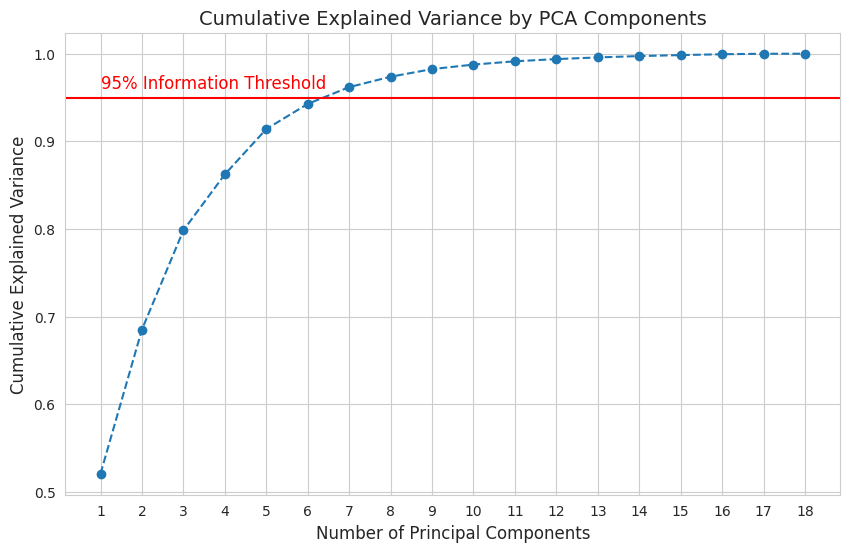

--- Variance Explained by Component ---
Components: 1 | Cumulative Variance: 52.09%
Components: 2 | Cumulative Variance: 68.54%
Components: 3 | Cumulative Variance: 79.85%
Components: 4 | Cumulative Variance: 86.24%
Components: 5 | Cumulative Variance: 91.40%
Components: 6 | Cumulative Variance: 94.27%
Components: 7 | Cumulative Variance: 96.19%


In [28]:
from sklearn.decomposition import PCA


# 1. Initialize PCA
# We let it build all 18 possible components so we can study them.
pca_exploratory = PCA(random_state=42)

# 2. Fit the PCA on the Training Data
# The algorithm calculates the mathematical vectors (Principal Components)
pca_exploratory.fit(X_train_u)

# 3. Calculate Cumulative Explained Variance
# explained_variance_ratio_ tells us how much % of data each component holds.
# np.cumsum() adds them up progressively (e.g., Comp 1 + Comp 2 + Comp 3...)
cumulative_variance = np.cumsum(pca_exploratory.explained_variance_ratio_)

# 4. Visualize the Scree Plot
plt.figure(figsize=(10, 6))
# Plot the cumulative variance as a line with dots
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# Draw a red horizontal line at 95% (Our target threshold for keeping information)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, '95% Information Threshold', color='red', fontsize=12)

# Graph decorations
plt.title('Cumulative Explained Variance by PCA Components', fontsize=14)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.xticks(range(1, 19)) # Force the X-axis to show numbers 1 through 18
plt.grid(True)
plt.show()

# 5. Print the exact numbers for the first few components
print("--- Variance Explained by Component ---")
for i in range(7):
    print(f"Components: {i+1} | Cumulative Variance: {cumulative_variance[i]*100:.2f}%")

## 8.2 Applying Dimensionality Reduction

Based on the Scree Plot analysis, exactly **7 Principal Components** are required to capture over 95% of the variance (specifically 96.19%).

We now instantiate a final PCA model to reduce our dataset from 18 dimensions down to 7.
**Leakage Prevention:** As with scaling, the PCA transformation matrix (the eigenvectors) is learned strictly from the Training data, and then applied to compress both the Train and Test sets.

In [29]:
# 1. Initialize the Final PCA Robot
pca_final = PCA(n_components=7, random_state=42)

# 2. Train the Robot and Compress X_train
# fit_transform calculates the 7 components AND squishes the data down into them.
X_train_pca = pca_final.fit_transform(X_train_u)

# 3. Compress X_test
# transform ONLY uses the math learned from X_train to squish the unseen Test data.
X_test_pca = pca_final.transform(X_test_u)

# 4. Wrap the results back into Pandas DataFrames
# We generate new column names like 'PC1', 'PC2', 'PC3'...
pc_columns = [f'PC{i+1}' for i in range(7)]

X_train_pca = pd.DataFrame(X_train_pca, columns=pc_columns, index=X_train_u.index)
X_test_pca = pd.DataFrame(X_test_pca, columns=pc_columns, index=X_test_u.index)

# 5. Verification
print("--- PCA Compression Successful ---")
print(f"Old Training Shape: {X_train_u.shape}")
print(f"New Training Shape: {X_train_pca.shape}")
print("-" * 30)
display(X_train_pca.head(3).round(2))

--- PCA Compression Successful ---
Old Training Shape: (676, 18)
New Training Shape: (676, 7)
------------------------------


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
508,0.07,0.59,0.17,0.25,0.68,1.28,-0.03
396,5.98,-3.71,-2.15,-0.34,-0.01,-2.49,1.21
51,-1.84,0.90,0.43,1.54,0.49,-0.68,-0.14


#**9. Unsupervised Clustering (K-Means)**

In [30]:
from sklearn.cluster import KMeans

# 1. Initialize the K-Means
# n_clusters=3: We tell it to look for 3 distinct piles (Car, Bus, Van)
# n_init=10: It will drop the magnets 10 different times and pick the best result
# random_state=42: Ensures we get the exact same clusters every time we run the code
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)

# 2. Training (Find the piles)
kmeans.fit(X_train_pca)

# 3. Assign the Data to Piles
train_clusters = kmeans.predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)

# 4. Verification
print("--- K-Means Clustering Complete ---")
print("First 15 predictions on Training Data:")
print(train_clusters[:15])
print("\nUnique clusters found:", set(train_clusters))

--- K-Means Clustering Complete ---
First 15 predictions on Training Data:
[0 1 0 2 0 0 1 1 2 1 0 2 2 1 2]

Unique clusters found: {np.int32(0), np.int32(1), np.int32(2)}


#**10. Unsupervised Evaluation & Comparison**

We must evaluate how well the blind clusters align with the true vehicle classes.
To do this, we:
1.  **Map the Clusters:** We assign a class name to each cluster based on the majority true label within that cluster.
2.  **Adjusted Rand Index (ARI):** A metric specifically designed for clustering that measures similarity between the predictions and the true labels (1.0 is perfect, 0.0 is random).
3.  **Confusion Matrix:** To visually compare the unsupervised results directly against the supervised Random Forest from Part 1.

--- How the Robot's Math translates to English ---
Cluster 0 is predominantly: VAN
Cluster 1 is predominantly: CAR
Cluster 2 is predominantly: CAR

--- Unsupervised Final Scores ---
Adjusted Rand Index (ARI): 0.084
Mapped Accuracy:           51.18%



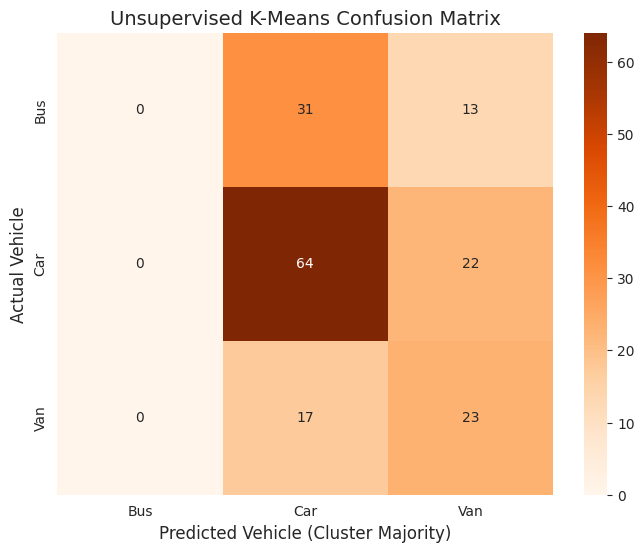

In [31]:

from sklearn.metrics import adjusted_rand_score, confusion_matrix, accuracy_score


# 1. Create a translator dataframe using the Test data
translation_df = pd.DataFrame({'True_Label': y_test_u, 'Cluster_Number': test_clusters})

# 2. Find the majority class in each cluster to build a dictionary
cluster_mapping = {}
for i in range(3):
    # Find all rows in this cluster, look at their true labels, and pick the most common one
    majority_label = translation_df[translation_df['Cluster_Number'] == i]['True_Label'].mode()[0]
    cluster_mapping[i] = majority_label

print("--- How the Robot's Math translates to English ---")
for num, label in cluster_mapping.items():
    print(f"Cluster {num} is predominantly: {label.upper()}")

# 3. Translate the robot's predictions into English words
y_pred_unsupervised = [cluster_mapping[num] for num in test_clusters]

# 4. Calculate Metrics
ari_score = adjusted_rand_score(y_test_u, test_clusters)
unsup_accuracy = accuracy_score(y_test_u, y_pred_unsupervised)

print("\n--- Unsupervised Final Scores ---")
print(f"Adjusted Rand Index (ARI): {ari_score:.3f}")
print(f"Mapped Accuracy:           {unsup_accuracy * 100:.2f}%\n")

# 5. Visual Comparison (Confusion Matrix)
cm_unsup = confusion_matrix(y_test_u, y_pred_unsupervised, labels=['bus', 'car', 'van'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_unsup, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bus', 'Car', 'Van'],
            yticklabels=['Bus', 'Car', 'Van'])

plt.title('Unsupervised K-Means Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Vehicle (Cluster Majority)', fontsize=12)
plt.ylabel('Actual Vehicle', fontsize=12)
plt.show()

#**11. Final Project Conclusion: Supervised vs. Unsupervised Learning**

This two-part project aimed to classify vehicle silhouettes using both labeled and unlabeled data. Comparing the two methodologies yields significant insights into the underlying structure of the dataset.

### 1. The Impact of Dimensionality Reduction
PCA successfully compressed the feature space from 18 dimensions down to 7 while retaining 96.19% of the explained variance. This proves that many of the original geometric features were highly correlated (e.g., scaled variances and scatter ratios) and could be mathematically streamlined without massive information loss.

### 2. Unsupervised Learning Findings (K-Means)
The unsupervised approach struggled significantly, achieving an ARI of 0.084 and a mapped accuracy of ~51%.
*   **Class Imbalance Impact:** Because the 'Car' class represents ~50% of the dataset, the density of the data points caused K-Means to assign two of its three centroids to the 'Car' region, completely failing to identify the 'Bus' cluster.
*   **Geometric Overlap:** K-Means relies on Euclidean distance and assumes spherical clusters. The poor performance confirms our EDA hypothesis: the geometric boundaries between these vehicles (especially Cars and Vans) are highly complex, overlapping, and non-spherical.

### 3. Supervised Learning Superiority (Random Forest)
In stark contrast, the supervised Random Forest achieved a **95.29% accuracy**. By having access to the target labels during training, the ensemble model was able to navigate the complex, non-linear feature space, successfully finding the subtle geometric rules that separate a Car from a geometrically similar Van.

### Final Business Recommendation for "Prospect Auto"
For a production environment, **Supervised Learning is strictly required**. While Unsupervised Learning (PCA) is highly valuable for data compression and understanding feature redundancy, distance-based clustering algorithms alone cannot overcome the natural geometric similarities between different vehicle classes. The Random Forest model from Part 1 should be deployed.